In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1 - Datuak lortu

* **California Housing Prices**: *Median house prices for California districts derived from the 1990 census.*

In [2]:
# Datu basearen esteka
url = "https://github.com/ageron/data/raw/main/housing.tgz"

# jaitsi eta deskonprimatu
!curl -L {url} | tar -xz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  438k  100  438k    0     0   638k      0 --:--:-- --:--:-- --:--:--  638k


* `!`: zerbitzariko ingurunean (*Linux shell*) exekutatuko den komandoa
* `curl` : *Transfer data from or to a server using URLs*
   * `-L` : *Follow re-location*  
* `|` (*pipe*): komando baten irteera hurrengo komandoaren sarrerarekin konektatu
* `tar` : *An archiving utility* (edukiak fitxategi bakarrean bildu)
   * `-x` : *Extract files from an archive*
   *  `-z` : *Filter the archive through gzip*

## 2 - Dataframe-a sortu eta bistaratu

CSV (Comma-Separated Values) formatuan dagoen taula **pandas**-eko *dataframe* bilakatu:

In [3]:
df = pd.read_csv("housing/housing.csv")

`df` dataframea bistaratu (pandas-ek zenbaki osoz osotutako indizea gehitzen dio):

In [4]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


Dataframeak indexatzeko aukera ezberdinak ditugu. Indexazioaren emaitza ilara/zutabe bakarra bada, emaitza `Series` motako objektu bat izango da. Beste kasuetan emaitza `DataFrame` motako objektu bat izango da:

In [5]:
data = df["total_bedrooms"]
print(type(data))
data

<class 'pandas.core.series.Series'>


0         129.0
1        1106.0
2         190.0
3         235.0
4         280.0
          ...  
20635     374.0
20636     150.0
20637     485.0
20638     409.0
20639     616.0
Name: total_bedrooms, Length: 20640, dtype: float64

In [6]:
data = df[["total_bedrooms","population"]]
print(type(data))
data

<class 'pandas.core.frame.DataFrame'>


,total_bedrooms,population
0,129.0,322.0
1,1106.0,2401.0
2,190.0,496.0
3,235.0,558.0
4,280.0,565.0
...,...,...
20635,374.0,845.0
20636,150.0,356.0
20637,485.0,1007.0
20638,409.0,741.0


In [7]:
data = df.iloc[0]
print(type(data))
data

<class 'pandas.core.series.Series'>


longitude              -122.23
latitude                 37.88
housing_median_age        41.0
total_rooms              880.0
total_bedrooms           129.0
population               322.0
households               126.0
median_income           8.3252
median_house_value    452600.0
ocean_proximity       NEAR BAY
Name: 0, dtype: object

In [8]:
data = df.iloc[10:20] # indizeko balioak mantendu egiten dira
print(type(data))
data

<class 'pandas.core.frame.DataFrame'>


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
10,-122.26,37.85,52.0,2202.0,434.0,910.0,402.0,3.2031,281500.0,NEAR BAY
11,-122.26,37.85,52.0,3503.0,752.0,1504.0,734.0,3.2705,241800.0,NEAR BAY
12,-122.26,37.85,52.0,2491.0,474.0,1098.0,468.0,3.0750,213500.0,NEAR BAY
13,-122.26,37.84,52.0,696.0,191.0,345.0,174.0,2.6736,191300.0,NEAR BAY
14,-122.26,37.85,52.0,2643.0,626.0,1212.0,620.0,1.9167,159200.0,NEAR BAY
15,-122.26,37.85,50.0,1120.0,283.0,697.0,264.0,2.1250,140000.0,NEAR BAY
16,-122.27,37.85,52.0,1966.0,347.0,793.0,331.0,2.7750,152500.0,NEAR BAY
17,-122.27,37.85,52.0,1228.0,293.0,648.0,303.0,2.1202,155500.0,NEAR BAY
18,-122.26,37.84,50.0,2239.0,455.0,990.0,419.0,1.9911,158700.0,NEAR BAY
19,-122.27,37.84,52.0,1503.0,298.0,690.0,275.0,2.6033,162900.0,NEAR BAY


## 3 - Datuak aztertu

* **longitude/latitude** : barrutiaren kokapena
* **housing_median_age**: barrutiko etxeen antzinatasunaren mediana
* **total_rooms**: gela kopuru totala (barrutiko etxe guztientzat)
* **total_bedrooms**: logela kopuru totala (barrutiko etxe guztientzat)
* **population**: barrutiko biztanle kopurua
* **households**: barrutiko etxe kopurua
* **median_income**: barrutiko biztanleen diru-sarreren mediana
* **median_house_value**: barrutiko etxeen prezioen mediana
* **ocean_proximity**: ozeanoarekiko hurbiltasuna

[`dataframe.info()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html) metodoak zutabeen laburpen sinple bat eskaintzen du:

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


[`dataframe.hist()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.hist.html) metodoak zutabeen histogramak marrazten ditu:

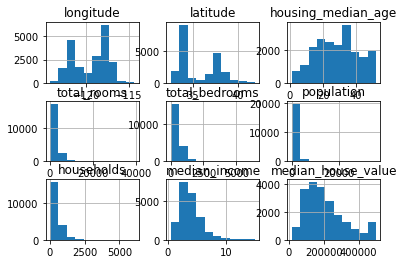

In [10]:
df.hist();

`df.hist();` vs `df.hist()` : Jupyter Notebook-ek gelaxkako azken adierazpenaren itzulera-balioa testu gisa erakusten du defektuz. `;` jartzea adierazpen horren irteera automatikoa ezkutatzen du.

`hist(..)` metodoaren argumentu batzuk:
* `bins`: Number of histogram bins to be used
* `figsize`: The size in inches of the figure to create

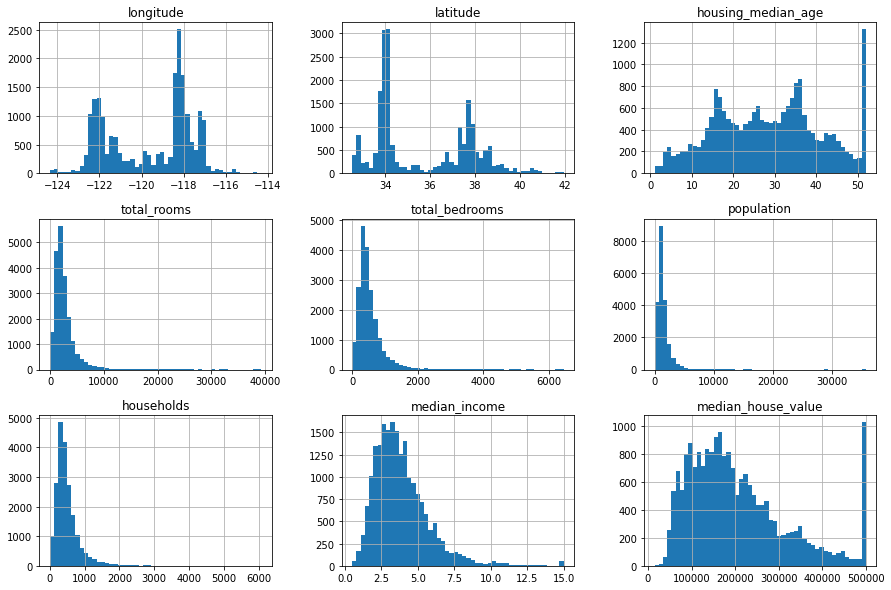

In [11]:
df.hist(bins=50, figsize=(15,10));

Histogramal behatzean:
* **housing_median_age**
    * $[1,52]$ tartera mugatua (52-n datu *arraroa*)
* **median_income**:
    * Eskala: ez dago dolarretan (\$10k)
    * $[0.5,15]$ tartera mugatua (\$150000etan datu *arraroa*)
* **median_house_value**
    * Eskala: dolarretan
    * $[15k,500k]$ tartera mugatua (\$500k-n datu *arraroa*) &rarr; helburu aldagaia bada, arazoa?
* Ezaugarriek eskala nahiko ezberdinak
* Orohar, banaketak ez dira simetrikoak (eskuineko alborapena dute) 

In [12]:
for c in ['housing_median_age', 'median_income', 'median_house_value']:
    print(f'{c} ∈ [{df[c].min()} , {df[c].max()}]')

housing_median_age ∈ [1.0 , 52.0]
median_income ∈ [0.4999 , 15.0001]
median_house_value ∈ [14999.0 , 500001.0]


Longitude/latitude ezaugarriak barrutien kokaguneak marrazteko erabil ditzakegu:

<AxesSubplot:xlabel='longitude', ylabel='latitude'>

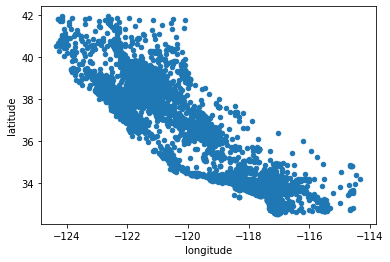

In [13]:
df.plot(x='longitude', y='latitude', kind='scatter')

Informazio gehiago gehitu dezakegu:
* Barruti bakoitzaren **populazioa**: puntuaren **tamaina**
* Batazbesteko etxeen **prezioa**: puntuaren **kolorea** 

<AxesSubplot:xlabel='longitude', ylabel='latitude'>

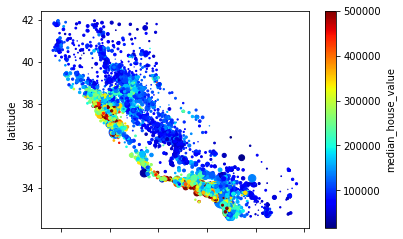

In [14]:
df.plot(
    kind='scatter',
    x='longitude', y='latitude',
    s=df['population']/200,
    c='median_house_value', cmap='jet', colorbar=True
)

FileNotFoundError: [Errno 2] No such file or directory: 'img/california.png'

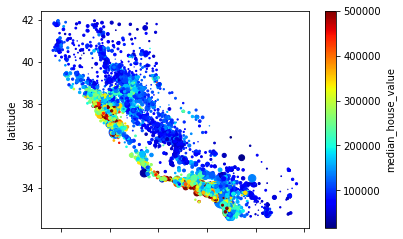

In [15]:
df.plot(
    kind='scatter',
    x='longitude', y='latitude',
    s=df['population']/200,
    c='median_house_value', cmap='jet', colorbar=True
)
california_img = plt.imread('img/california.png')
axis = -124.55, -113.95, 32.45, 42.05
plt.axis(axis)
plt.imshow(california_img, extent=axis)

plt.show()

## 4 - Train/Test banaketa egin

Testerako datuen %20a erreserbatuko dugu. *Scikit-learn*-eko `train_test_split()` funtzioa erabiliko dugu:

In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)
print(f'{df.shape = }')
print(f'{train.shape = }')
print(f'{test.shape = }')
#train
#test

* `random_state=...`: exekutatzen dugun bakoitzean sasi-auzazkotasun generatzaileak hazi berdina erabiliko du, **erreproduzigarritasuna** bermatuz.
* `42`: edozein balio izan daiteke ([El sentido de la vida, el universo y todo lo demás: 42](https://es.wikipedia.org/wiki/El_sentido_de_la_vida,_el_universo_y_todo_lo_dem%C3%A1s)) https://www.youtube.com/watch?v=W5dPnXaMcWw

Train/Test banaketa egitean, jatorrizko indizea mantentzen da:

In [ ]:
train.head()

`.reset_index(drop=True)` funtzioak indizea berritzen du.
* `drop=True` : defektuz indize zaharra ezaugarri gisa mantentzen du.

In [ ]:
train.reset_index(drop=True).head()

In [ ]:
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)
#train
#test

## 5 - Aldagai iragarleak eta helburu-aldagaia ezberdindu 

Oraingoz:
* Helburu-aldagaia: **median_house_value**
* Aldagai iragarleak: beste guztiak

In [ ]:
X_train = train.drop(columns=['median_house_value'])
y_train = train['median_house_value'].copy() # bertsio berrietan .copy() ez da beharrezkoa, Copy-on-Write
#X_train
#y_train

**Copy-on-Write**: `train['median_house_value']`-k zutabe originalaren *view* bat bueltatzen du: `y_train`-en aldaketak egitean, `train`-eko zutabean aldaketak egingo genituzke. Pandas-en bertsio berriek (≥3.0) *Copy-on-Write* propietatea dute, `y_train` aldatzera goazenean datuen kopia bat sortzen da eta `train`-eko zutabean ez da aldaketarik gertatzen. 

Entrenamendu-multzoan aplikatzen diren eraldaketa guztiak testean ere aplikatu behar dira, beraz errazena da DataFrame bati aplikatu beharreko eraldaketa guztiak funtzio baten bidez adieraztea:

In [ ]:
def preprocessing(df):
    X = df.drop(columns=['median_house_value'])
    # y = df['median_house_value'].copy()
    # DataFrameak helburu-aldagairik ez balu...
    y = df['median_house_value'].copy() if 'median_house_value' in df.columns else None
    return X,y

X_train, y_train = preprocessing(train)
X_test, y_test = preprocessing(test)
print(f'{train.shape = }  {X_train.shape = }  {y_train.shape = }')
print(f'{test.shape = }  {X_test.shape = }  {y_test.shape = }')
#X_train
#y_train
#X_test
#y_test

## 7 - Ezaugarrien konbinaketa

Ezaugarrietako batzuk barruti bakoitzeko balio totalak dira (barrutian dauden etxe kopuruarekin handitzen dira) eta ez dute erabilgarritasun handirik barruti batetako ezaugarri gisa:

* **total_rooms**: gela kopuru totala (barrutiko etxe guztientzat)
* **total_bedrooms**: logela kopuru totala (barrutiko etxe guztientzat)

Zentzuzkoagoa litzateke etxebizitza baten batazbesteko gela eta logela kopurua izatea ezaugarria:
* **rooms_ph** (*average rooms per household*): `total_rooms/households`
* **bedrooms_ph** (*average rooms per household*): `total_bedrooms/households`

Ezaugarri originalak ezabatu ditzakegu:

In [ ]:
def preprocessing(df):
    df = df.copy() # ematen diguten dataframe-a ez aldatzeko...
    
    df['rooms_ph'] = df['total_rooms'] / df['households']
    df['bedrooms_ph'] = df['total_bedrooms'] / df['households']
    df = df.drop(columns=['total_bedrooms','total_rooms'])
    
    X = df.drop(columns=['median_house_value'])
    y = df['median_house_value'].copy() if 'median_house_value' in df.columns else None
    return X,y

X_train, y_train = preprocessing(train)
X_test, y_test = preprocessing(test)
print(f'{train.shape = }  {X_train.shape = }  {y_train.shape = }')
print(f'{test.shape = }  {X_test.shape = }  {y_test.shape = }')
#X_train
#y_train
#X_test
#y_test

## 6 - Balio galduak 

Balio galduak edonon agertu daitezke:

In [ ]:
X_train.isnull().sum()

Test-eko datuetan zer gertatuko den ezin dugu aurrez jakin, hala ere hemen tranpa txiki bat egingo dugu:

In [ ]:
X_test.isnull().sum()

Balio galdu hauen iturria *total_bedrooms* ezaugarria izan da:

In [ ]:
df.isnull().sum()

Aldagai kuantitatiboetan ohikoa da balio galduen ordezkapenean mediana erabiltzea.
* Mediana **train-eko datuetan zenbatetsi behar da**
* Bi fase:
   * Medianaren estimazioa (**train**) &rarr; aurreprozesatzearen barne parametro bat
   * Aurreprozesatzea aplikatzea (**train+test**)

**OHARRA:** Hau ezaugarri guztiekin egin beharko genuke, izan ere ezin dugu ziurtatu zer gerta daitekeen aurrerago. Hala ere, kasu honetan `bedrooms_ph` aldagaiean aztertuko dugu balio galduen problema.

*Scikit-learn*-ek eraldaketak doitzen/zenbatesten eta aplikatzen dituzten **transformer**-ak ditu. Orohar onako moduan erabiltzen dira:

```python
transformer = SomeTransformer()
transformer.fit(train_data)
train_data_new = transformer.transform(train_data)
test_data_new = transformer.transform(test_data)
```

Gure datuen aurreprozesatze guztiaz arduratzen den antzeko objektu bat sor genezake:

```python
class Preprocessor(object):
    def __init__(self):
        # fit() egitean doitu beharreko barne parametroak sortu
        ...
        
    def fit(self, df):
        # barne parametroak doitu
        ...
        return self # konbentzioz, fit-ek self bueltatzen du
        
    def transform(self, df):
        df = df.copy() # ematen diguten dataframe-a ez aldatzeko...
        # Egin beharreko transformazio guztiak aplikatu
        ...
        # X eta y bereiztu
        ...
        return X, y
```

Eta erabiltzeko:

```python
preprocessor = Preprocessor()
preprocessor.fit(train)
X_train, y_train = preprocessor.transform(train)
X_test, y_test = preprocessor.transform(test)
```

### Preprocessor klasearen inplementazioaren arazoa

`rooms_ph`-ren mediana zenbatestera goazenean, datuak ez daude prest (`fit` `transform` aurretik exekutatzen da):
* `rooms_ph` eta `bedrooms_ph` **ez dira existitzen**

```python
class Preprocessor:
    def __init__(self):
        # fit() egitean doitu beharreko barne parametroak sortu
        self.bedrooms_ph_median = None
    
    def fit(self, df):
        # barne parametroak doitu
        self.bedrooms_ph_median = df['bedrooms_ph'].median()
        return self # konbentzioz, fit-ek self bueltatzen du
        
    def transform(self, df):
        df = df.copy() # ematen diguten dataframe-a ez aldatzeko...
        # Egin beharreko transformazio guztiak aplikatu
        df['rooms_ph'] = df['total_rooms'] / df['households']
        df['bedrooms_ph'] = df['total_bedrooms'] / df['households']
        df = df.drop(columns=['total_bedrooms','total_rooms'])
        df['bedrooms_ph'] = df['bedrooms_ph'].fillna(self.bedrooms_ph_median)
        # X eta y bereiztu
        X = df.drop(columns=['median_house_value'])
        y = df['median_house_value'].copy() if 'median_house_value' in df.columns else None
        return X, y
```

Bigarren transformazio fasearen (*Balio galduak*) barne parametroak doitzeko (`fit`) aurreko fasearen (*Ezaugarrien konbinaketa*) transformazioa dagoeneko aplikatua egon behar da. Orohar, $i$. fasearen barne parametroak doitzeko $1,2,\dots,i-1$ faseen transformazioa dagoeneko aplikatuta egotea behar da.

Problema hau ebazteko, transformazio fase bakoitza bere *transformer* clase propioarekin adierazi dezakegu eta aurreprozesatze guztia egingo duen `Preprocessor` *transformer*-a haien menpe jarri:

### 1. `FeatureCombinator` : Ezaugarrien konbinaketa

In [ ]:
class FeatureCombinator:
    def __init__(self):
        pass
        
    def fit(self, df):
        return self
        
    def transform(self, df):
        df['rooms_ph'] = df['total_rooms'] / df['households']
        df['bedrooms_ph'] = df['total_bedrooms'] / df['households']
        df = df.drop(columns=['total_bedrooms','total_rooms'])
        return df

### 2. `MedianFiller` : Balio galduak

In [ ]:
class MedianFiller:
    def __init__(self):
        self.bedrooms_ph_median = None
        
    def fit(self, df):
        self.bedrooms_ph_median = df['bedrooms_ph'].median()
        return self
        
    def transform(self, df):
        df['bedrooms_ph'] = df['bedrooms_ph'].fillna(self.bedrooms_ph_median)
        return df

### 3. `Preprocessor` : Aurreprozesatze osoa

In [ ]:
class Preprocessor:
    def __init__(self, transformers):
        self.transformers = transformers
            
    def fit(self, df):
        df = df.copy()
        for t in self.transformers:
            # t.fit(df)
            # df = t.transform(df)
            df = t.fit(df).transform(df)
        return self
    
    def transform(self, df):
        df = df.copy()
        for t in self.transformers:
            df = t.transform(df)

        X = df.drop(columns=['median_house_value'])
        y = df['median_house_value'].copy() if 'median_house_value' in df.columns else None
        
        return X, y

In [ ]:
preprocessor = Preprocessor([FeatureCombinator(), MedianFiller()])
preprocessor.fit(train)
X_train, y_train = preprocessor.transform(train)
X_test, y_test = preprocessor.transform(test)

print(f'df["total_bedrooms"] balio galduak: {df['total_bedrooms'].isnull().sum()}')
print(f'X_train["bedrooms_ph"] balio galduak: {X_train['bedrooms_ph'].isnull().sum()}')
print(f'X_test["bedrooms_ph"] balio galduak: {X_test['bedrooms_ph'].isnull().sum()}')
#X_train
#y_train
#X_test
#y_test

Aurreprosezatzea beste momenturen batean erabili nahiko bagenu, gorde egin beharko genuke nolabait. `joblib` liburutegia erabili dezakegu:

In [ ]:
import joblib

# Aurreprosezatzailea fitxategi batean gorde
joblib.dump(preprocessor, "preprocessor.data")

Aurrerago, nahi dugunean berreskuratu dezakegu:

In [ ]:
# Aurreprosezatzailea fitxategi batetik kargatu
preprocessor2 = joblib.load("preprocessor.data")

X_test2, y_test2 = preprocessor2.transform(test)
#X_test2
#y_test2

## 8 - Ezaugarri kategorikoak bektorizatu

Eredu askok ezaugarri kuantitatiboak ametitzen dituzte soilik. Datubaseko **ocean_proximity** ezaugarria kategorikoa da: 

In [ ]:
df['ocean_proximity']

Eta denera 5 kategoria ezberdin ageri dira soilik:

In [ ]:
#set(train['ocean_proximity'])
df['ocean_proximity'].unique()

**One-Hot-Encoding**: $\{c_1, c_2, \dots , c_k\}$ kategoria edo balio posible dituen ezaugarri kategoriko bat aldagai kuantitatibo bilakatzeko modu sinple bat $k$ tamainako bektore bat sortzea da. Bektoreko posizio gehienen balioa $0$ izango da, bat izan ezik, aldagaiaren balioari dagokiona. Adibidez, aldagaiaren balioa $c_i$ denean, ordezkatuko dugun $v=[v_1,v_2,\dots,v_k]$ bektorearen balioa ondokoa da:
$$
v_j = \begin{cases} 
0, & j \ne i \\ 
1, & j = i 
\end{cases}
$$

Pandasek ba du ezaugarri kategorikoak erraz bektorizatzeko balio duen `pd.get_dummies()` funtzioa:

In [ ]:
pd.get_dummies(df['ocean_proximity'], dtype=int)

In [ ]:
pd.get_dummies(train, columns=['ocean_proximity'], dtype=int)

Hala ere, eraldaketa hau hasera-haseratik egin beharko litzateke, izan ere test-eko azpimultzoan kategoriaren bat faltako balitz, gauza arraroak gerta litezke. Adibidez, gure datubasean ez daude `'ISLAND'` balioa duten adibide asko: 

In [ ]:
print((df['ocean_proximity']=='ISLAND').sum())

eta kasualitatez denak entrenamendu azpimultzoan erori dira:

In [ ]:
print(f'Entrenamenduan: {(train['ocean_proximity']=='ISLAND').sum()}')
print(f'Testean: {(test['ocean_proximity']=='ISLAND').sum()}')

Hau dela eta, `pd.get_dummies()` funtzioa test-eko azpimultzoan aplikatzean, emaitzako dataframearen egitura ezberdina da (`15 columns` vs `16 columns`):

In [ ]:
pd.get_dummies(test, columns=['ocean_proximity'], dtype=int)

In [ ]:
print(pd.get_dummies(train, columns=['ocean_proximity'], dtype=int).shape)
print(pd.get_dummies(test, columns=['ocean_proximity'], dtype=int).shape)

Egoera hau ekiditeko, *Scikik-learn*-en `OneHotEncoder` kodetzailea erabili dezakegu. Kodetzaile honek entrenamenduko datuetan doitu daiteke (existitzen diren klaseak aztertu) eta ondoren beste edozein daturekin erabili:

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# 1. Encoderra/Kodetzailea hasieratu
# sparse_output=False matrize dentsoa itzultzen du (beharrezkoa da Pandaserako)
# handle_unknown='ignore' testak kategoria berriak baditu, ez egin akatsik
# drop='first' lehenengo zutabea ezabatu erlazio linealik ez egoteko (dummy variable trap)
# feature_name_combiner=... sortutako zutabeen izenak ezartzen dituen funtzioa
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore',
    drop='first',
    feature_name_combiner=lambda column, cathegory : str(cathegory)
)

# Kodetzailearen emaitza Pandas-eko DataFrame izaten jarrai dezan
encoder.set_output(transform="pandas")

# 2. Encoderra doitu. OneHotEncoder-ak nx1 gisako matrize egitura espero du, df[['name']]
encoder.fit(X_train[['ocean_proximity']])

# 3. Kodetzailea aplikatu. OneHotEncoder-ak nx1 matrize egitura espero du, df[['name']]
encoder.transform(X_train[['ocean_proximity']]).head()

* `df['col_name']` &rarr; `pandas.Series ($n$ tamainako bektore egitura)
* `df[['col_name']]` (fancy indexing) &rarr; `pandas.DataFrame` ($n \times 1$ tamainako matrize egitura)

In [ ]:
print(f'{type(df['ocean_proximity']) = }')
print(f'{type(df[['ocean_proximity']]) = }')
print(f'{df['ocean_proximity'].shape = }')
print(f'{df[['ocean_proximity']].shape = }')

Sortutako zutabe berriak DataFrame zaharrarekin bildu behar dira eta *ocean_proximity* zutabea ezabatu:

In [ ]:
df1 = X_train.drop(columns=['ocean_proximity'])
df2 = encoder.transform(X_train[['ocean_proximity']])
pd.concat([df1,df2], axis=1).head()

OneHotEncoderra aurreprozesatzearen fase bat gehiago izango da, **entrenamenduko datuekin doitu neharko dena**, `total_bedrooms_median` parametroarekin gertatzen zen moduan:

In [ ]:
class CathegoryVectorizer:
    def __init__(self):
        self.ocean_proximity_encoder = OneHotEncoder(
            sparse_output=False,
            handle_unknown='ignore',
            drop='first',
            feature_name_combiner=lambda column, cathegory : str(cathegory)
        )
        self.ocean_proximity_encoder.set_output(transform="pandas")
        
    def fit(self, df):
        self.ocean_proximity_encoder.fit(df[['ocean_proximity']])
        return self
        
    def transform(self, df):
        df = pd.concat([
            df.drop(columns=['ocean_proximity']),
            self.ocean_proximity_encoder.transform(df[['ocean_proximity']])
        ], axis=1)
        return df

preprocessor = Preprocessor([FeatureCombinator(), MedianFiller(), CathegoryVectorizer()])
preprocessor.fit(train)
X_train, y_train = preprocessor.transform(train)
X_test, y_test = preprocessor.transform(test)

X_train
#y_train
#X_test
#y_test

### Hausnarketa
Zentzuzkoa al da `'ocean_proximity'=='ISLAND'` duten 5 lagin horiek mantentzea? ML eredua gai izango ote da 5 lagin horiek duten egitura barneratzeko? Gure kasuan ez dio gehiegi ajola, guztiak entrenamenduan erori direlako, baina laginak baztertzea ere aukera bat da. 

In [ ]:
print(f'Baztertuko diren laginak: {(df['ocean_proximity']=='ISLAND').sum()}')
print(f'{df.shape = }')
df = df[df['ocean_proximity']!='ISLAND']
print(f'ISLAND laginak DataFrame berrian: {(df['ocean_proximity']=='ISLAND').sum()}')
print(f'{df.shape = }')

Eta haseratik pausu guztiak berriro eman:

In [ ]:
train, test = train_test_split(df, test_size=0.2, random_state=42)
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

preprocessor = Preprocessor([FeatureCombinator(), MedianFiller(), CathegoryVectorizer()])
preprocessor.fit(train)
X_train, y_train = preprocessor.transform(train)
X_test, y_test = preprocessor.transform(test)

#X_train
#y_train
#X_test
#y_test

## 9 - Balio arraroak topatu

Noizbehinka interesgarria da balio arrarorik ote dugun konprobatzea. 

In [ ]:
X_train.drop(columns=['INLAND','NEAR BAY','NEAR OCEAN']).describe()

Lau kasu aztertuko ditugu:
* $max(bedrooms\_ph)=34.066667$
* $max(rooms\_ph)=132.533333$
* $min(bedrooms\_ph)=0.333333$
* $min(rooms\_ph)=0.888889$

Maximo/minimoak topatzeko `argmax()` eta `argmin()` funtzioak erabil ditzakegu

### 1. $max(bedrooms\_ph)=34.066667$

In [ ]:
i = X_train['bedrooms_ph'].argmax()
print(f'indizea: {i}')
train.iloc[i]

Apur bat arraroa dirudi 15 etxeetan 511 logela egotea...

### 2. $max(rooms\_ph)=132.533333$

In [ ]:
i = X_train['rooms_ph'].argmax()
print(f'indizea: {i}')
train.iloc[i]

Apur bat arraroa ere, 15 etxeetan 1988 gela egotea... Ohar bat: aurreko bi laginak berdinak dira, (`indizea: 5231`).

### 3. $min(bedrooms\_ph)=0.333333$

In [ ]:
i = X_train['bedrooms_ph'].argmin()
print(f'indizea: {i}')
train.iloc[i]

9 etxebizitza, baina denera 3 logela. Logelarik gabeko etxebizitzak?

### 4. $min(rooms\_ph)=0.888889$

In [ ]:
i = X_train['rooms_ph'].argmin()
print(f'indizea: {i}')
train.iloc[i]

36 etxebizitza, baina denera 32 gela. Gelarik gabeko etxebizitzak?

### Hausnarketa
Halako egoeretan datuak zuzenak ote diren galdetu beharko genioke gure buruari. Erroreak dituzten lagin guztiekin zerbait egin beharko genuke:
* Balioak ordezkatu
* Laginak baztertu

Kasu honetan, datuetan errorerik ez dagoela suposatuko dugu.

## 10 - Ezaugarri kuantitatiboak estandarizatu

Eredu batzuk ezaugarri kuantitatiboen eskalarekiko sentikortasun handia izan dezakete. 

In [ ]:
X_train.drop(columns=['INLAND','NEAR BAY','NEAR OCEAN']).hist(bins=50, figsize=(15,10));

**Estandarizazioa** (*Z-score*): Datuak eraldatzen ditu, 0 batez bestekoa eta 1 desbiderapen estandarra izan dezaten. $\mu$ datuen batez bestekoa bada eta $\sigma$ haien desbiderapen estandarra, orduan estandarizazioak ondoko transformazioa aplikatzen du:

$$x' = \frac{x - \mu}{\sigma}$$

Noiz erabili ohi da:
* Datuen banaketa normal baten araberakoak direnean.
* Ereduak banaketa normal bat espero duenean (**KONTUZ**, datuak gaussiarrak ez badira, emaitza ez da gausiarra izango)

*Scikit-learn*-eko StandardScaler erabili dezakegu estandarizazio transformazio bat zenbatetsi (entrenamenduan) eta edozein datu berritan aplikatzeko:

In [ ]:
from sklearn.preprocessing import StandardScaler

df_tmp = X_train[['median_income']]
scaler = StandardScaler() 
scaler.fit(df_tmp)
df_tmp['median_income_standarized'] = scaler.transform(df_tmp)
df_tmp.hist(bins=50, figsize=(10,3.3));

In [ ]:
X_train.iloc[0]

In [ ]:
class Standarizer:
    def __init__(self):
        columns = ['longitude','latitude','housing_median_age','population','households','median_income','rooms_ph','bedrooms_ph']
        self.standarizers = {column:StandardScaler() for column in columns}
        
    def fit(self, df):
        for column,scaler in self.standarizers.items():
            scaler.fit(df[[column]])
        return self
        
    def transform(self, df):
        for column,scaler in self.standarizers.items():
            df[column] = scaler.transform(df[[column]])
        return df

preprocessor = Preprocessor([FeatureCombinator(), MedianFiller(), CathegoryVectorizer(), Standarizer()])
preprocessor.fit(train)
X_train, y_train = preprocessor.transform(train)
X_test, y_test = preprocessor.transform(test)

X_train.hist(bins=50, figsize=(15,10));
#X_train
#y_train
#X_test
#y_test

### Hausnarketa
Helburu aldagaia ez dugu estandarizatu:

In [ ]:
pd.DataFrame(y_train).hist(bins=50, figsize=(5,3.3))

Hau arazo bat izan liteke eredu batzuentzat. Beste ezaugarri kuantitatiboekin jokatu dugun moduan, estandarizazio bat aplikatzea zentzuzkoa da, dena den horrek apur bat zailtzen du emaitzen interpretazioa eta beraz ez dugu egingo (estandarizazioa transformazio itzulgarria da, ez legoke arazo larririk).